In [1]:
# (make sure you are using datahub!)

# PyTorch 
# Deep-learning framework developed by Meta (Facebook!) 
# We can use it to train AI models to help recognize patterns in data

# What are we doing today?
# We will use a computer to find hidden pattern in data 
# Unlike what we doing today... the universe doesn't give neat answers
# We have to work to find them, pytorch is just another tool to help us
# find answers in data 
# We used numpy to manipuate arrays, scipy to fit curves, etc

In [2]:
# Outline for today
# 0) Install Pytorch + some vocab
# 1) Get our data
# 2) Build a model (deep learning)
# 3) Train our model (machine learning)
# 4) Evaluate our model
# 5) Compare our model's results to the actual hidden pattern
# 6) Improve our model

In [4]:
# 0) Install Pytorch

# We first gotta call this really long and weird import statement
# Go to data.py to find it, call the following in a cell 
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

In [5]:
# 0) Some vocabulary
# Model = a function that can learn patterns from data

# Training = the process of making predictions more accurate by minimizing error

# AI (artificial intelligence) = biggest umbrella term, computers that are
# designed to perform tasks like human intelligence (recognizing patterns,
# making decisions, learning from experience). 

# ML (machine learning) = subset of AI, computers that learn from data instead
# of programmed with explicitly, more data = better predictions

# DL (deep learning) = subset of ML, uses neural networks with multiple layers
# to process data, good at complex patterns, uses neurons to map inputs to 
# outputs

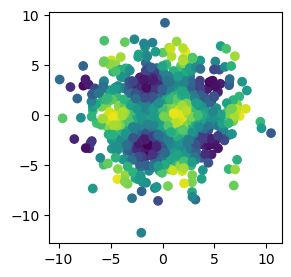

In [1]:
# 1) Get our data
# Import our data
import data

# A module that I wrote that contains our data for today
# The data contains a hiddne pattern we will use a neural network to find!
# Let's look at our data so far

import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

# What does this all mean?
# Creating a scatter plot
# We have x and y coordinates
# Our hidden pattern is given by the colors 
# Goal: Build a neural network to find the hidden pattern!

In [2]:
# 2) Build a model
# What is a model?
# A model is essentially just math. It is a function that maps inputs to 
# outputs. It can learn patterns from data. 

import torch # This is PyTorch

model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), # Input layer -> Hidden layer
    torch.nn.Sigmoid(), # Activation function
    torch.nn.Linear(50, 1) # Hidden layer -> Output layer
)

# This is condensed notation for:

# torch.nn.Sequential = conveyer belt
# Data enters via input layer -> processed by hidden layer -> leaves in output layer

# torch.nn.Linear(2, 50) = takes two inputs (x, y) passes them to 50 neurons
# Then this layer learns weights biases to adjust inputs 
# and make better predictions

$$
\text{output} = \text{input} \times \text{weights} + \text{bias}
$$

In [8]:
# torch.nn.Sigmoid() = activation function, introduces non-linearity into model
# Lines are too simple! We need curvy stuff!
# Sigmoid function takes a number and puts it between 0 and 1
# Helps neurons work in a smoother and more continous way

# torch.nn.Linear(50, 1) = our 50 neurons are mapped to 1 output value
# So we entered with two values and are leaving with single number
# hiddern pattern! 

In [3]:
# 3) Train our model
# Training = adjusting parameters to minimize errors

# parameters:
# weights = strength of the connection between our neurons
# biases = small adjustments added to neurons to improve learning
# It starts with random values and then adjust them during training

# We have a loss function + an optimizer
# A) loss function = how wrong our model is 
# B) optimizer = updates our model's parameters to minimize the loss

# A) Loss Function
# We will use mean squared error (MSE) 
loss_fn = torch.nn.MSELoss()
# MSE will measure the average squared difference between the predicted
# and the actual values

# B) Optimizer 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# We are using an Adam Optimizer
# model.parameters = the weights and biases that we are updating
# 1r = 1e-3, is the learning rate (small = slow + control, larger = fast + risky)

# Training loop 
# The model improves every iteration
# Bear with me: 

for t in range(1000):
    y_pred = model(data.x)            # Make a prediction
    loss = loss_fn(y_pred, data.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

# Predicts an output
# Measure how well the prediction matches the data, gradient tells our model how to adjust the weights
# Resets the gradients (such that its different for each calculation)
# Compute how much our parameters then need to change
# Adjust the weights and biases 
# Print the loss (difference between data and model)

Iteration 0, Loss: 1.032326340675354
Iteration 100, Loss: 0.9756048917770386
Iteration 200, Loss: 0.9144945740699768
Iteration 300, Loss: 0.8014140725135803
Iteration 400, Loss: 0.6571527123451233
Iteration 500, Loss: 0.5355691909790039
Iteration 600, Loss: 0.4547421336174011
Iteration 700, Loss: 0.39996612071990967
Iteration 800, Loss: 0.36144348978996277
Iteration 900, Loss: 0.333718478679657


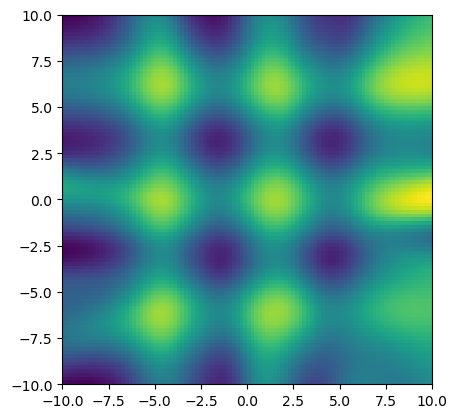

In [16]:
# 4) Evaluate our model
new_x = torch.linspace(-10, 10, 100) # 1D array of values
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2) # Making our y, meshing them together

output = model(grid).detach() # just evalutating, taking the x/y pairs and predicting a "z"

output = output.squeeze(2).t() # Making it the right dimension
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

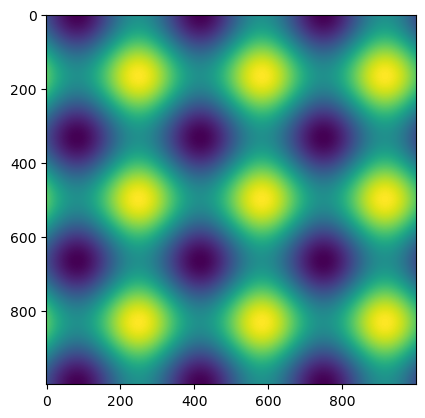

In [4]:
# 5) Compare our model's results to the actual hidden pattern
plt.imshow(data.pattern)
plt.show()

In [ ]:
# 6) Improve our model
# Increase neuron count
# Add more layers
# Adjust learning rate
# Train for longer
# Don't use Sigmoid, use ReLU